In [2]:
from probjax.distributions import *
from probjax.distributions.transformed_distribution import TransformedDistribution
import jax
import jax.numpy as jnp
from probjax.core.custom_primitives.random_variable import rv

from jax.api_util import flatten_fun_nokwargs


import matplotlib.pyplot as plt
key = jax.random.PRNGKey(0)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Distributions

Just testing some of the distributions

In [42]:
a = jnp.linspace(0, 1, 200).reshape((40,5))
values = jnp.linspace(0, 2, 100).reshape((20,5))
jnp.isin(values, a)

jnp.all(jnp.isin(values, a), axis = (i for i in range(1, values.ndim)))

Array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False], dtype=bool)

## Continous Distributions

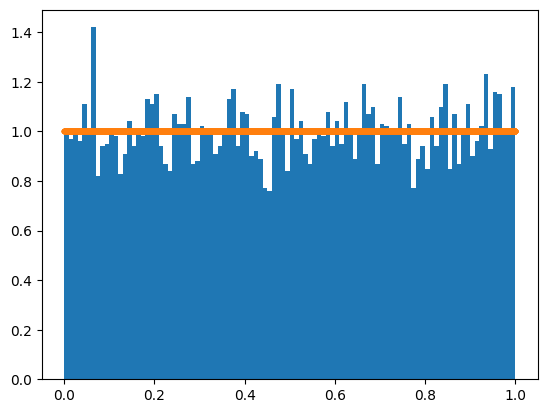

In [2]:
p = Uniform(low=0., high=1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


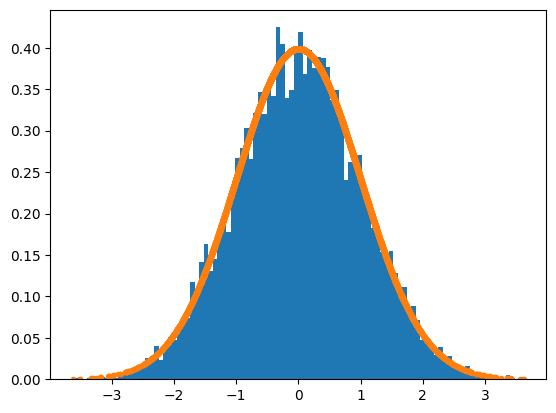

In [3]:
p = Normal(0.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


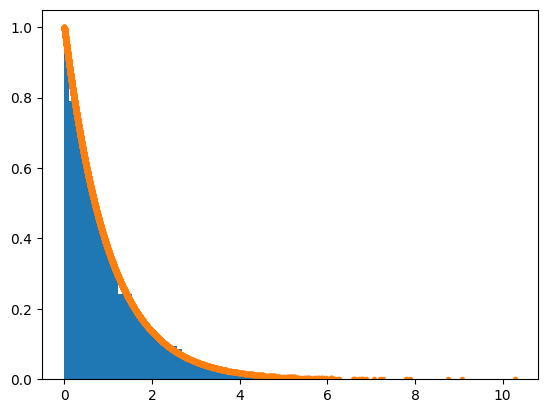

In [4]:
p = Gamma(1.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


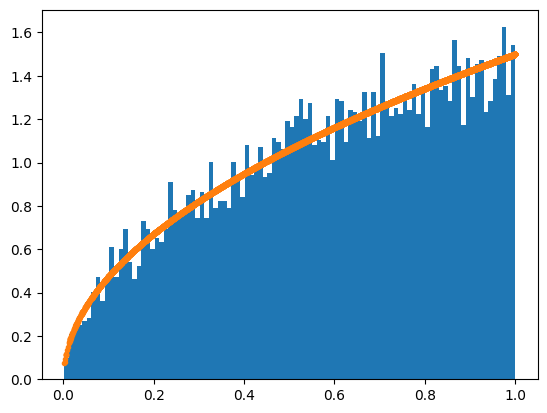

In [5]:
p = Beta(1.5,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


Array(True, dtype=bool)

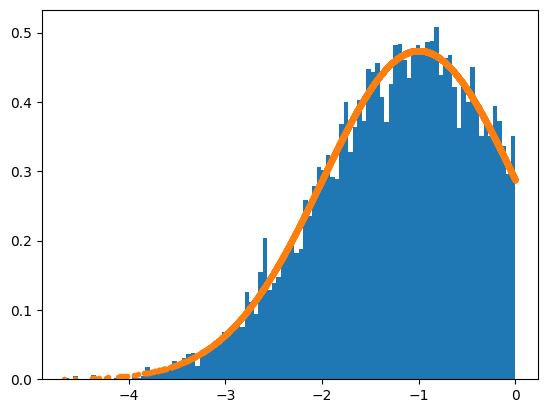

In [6]:
p = TruncatedNormal(-1.,1., low=-100., high=1.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
jnp.isfinite(log_prob).all()

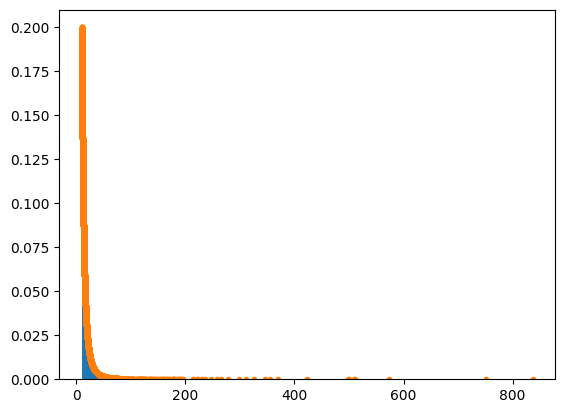

In [7]:
p = Pareto(2.,10.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

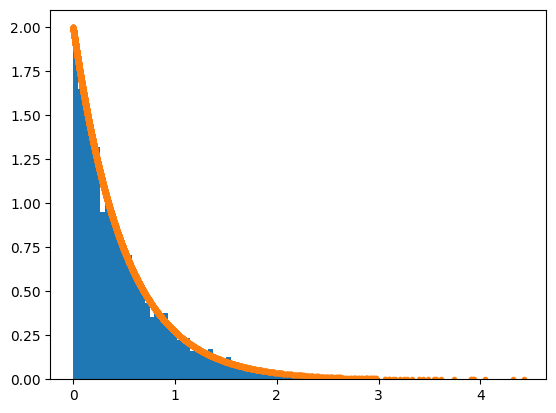

In [8]:
p = Exp(2.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

Array(-3.936, dtype=float32)

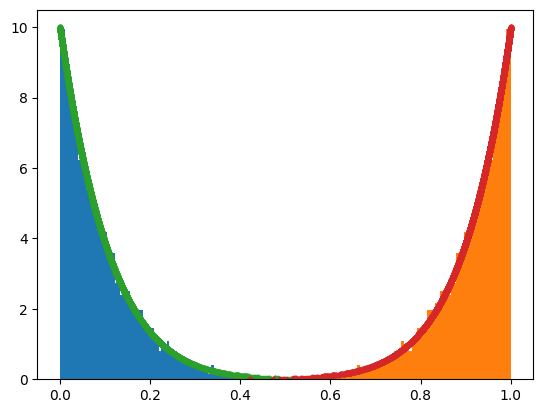

In [9]:
p = Dirichlet(jnp.array([1.,10.]))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

p.log_prob(jnp.array([0.5,0.5]))


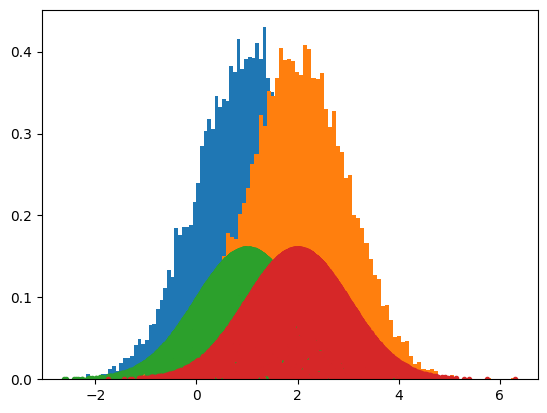

In [10]:
p = MultivariateNormal(jnp.array([1.,2.]), jnp.eye(2))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


## Mixture

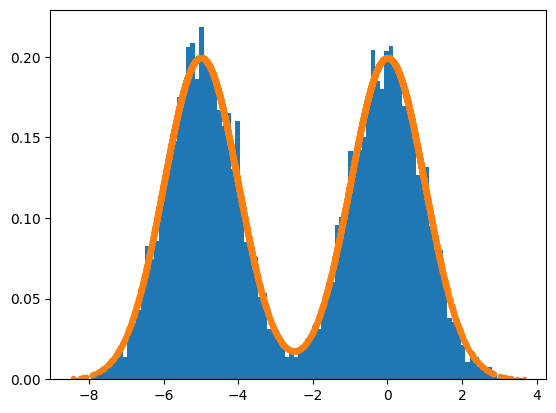

In [11]:
p1 = Normal(0.,1.)
p2 = Normal(-5.,1.)

p = Mixture(jnp.array([0.5,0.5]), [p1,p2])
samples = p.sample(key, (10000,))
_ = plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

## Discrete

(0.0, 1.0)

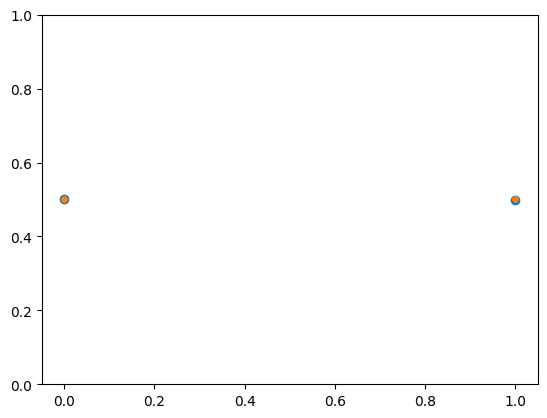

In [12]:
p = Bernoulli(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

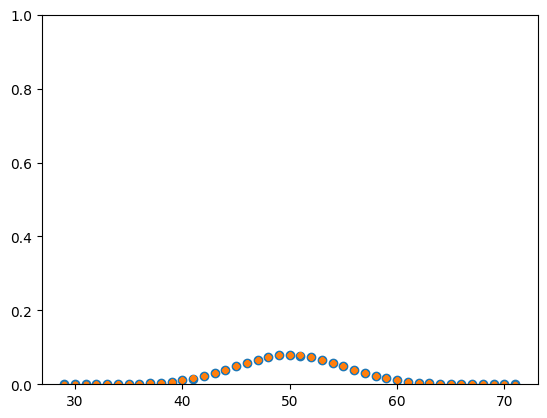

In [13]:
p = Binomial(100, jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

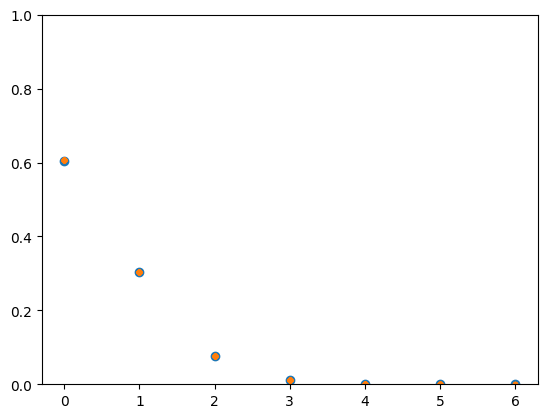

In [14]:
p = Poisson(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

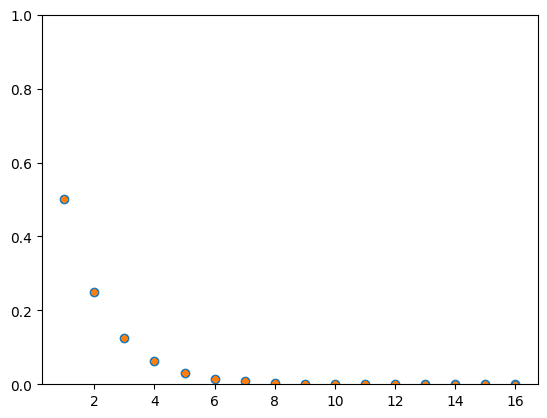

In [15]:
p = Geometric(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

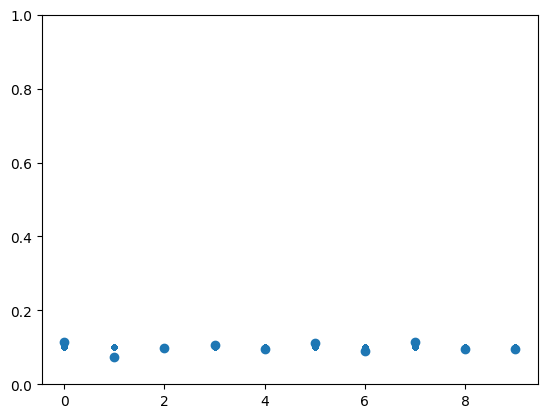

In [17]:
p = Categorical(jnp.ones((10)))
samples = p.sample(key, (1000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/1000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

In [6]:
log_prob.shape

(10000, 1, 1)

(0.0, 1.0)

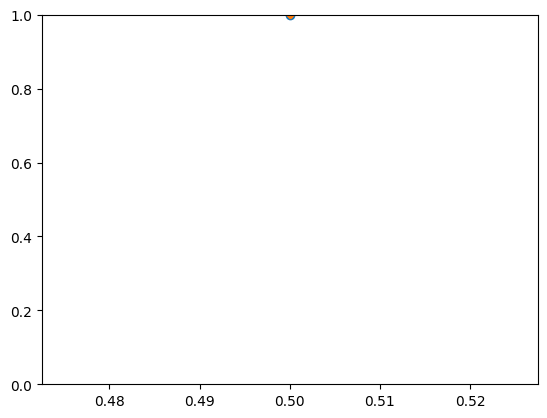

In [18]:
p = Dirac(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

ValueError: x and y can be no greater than 2D, but have shapes (10000, 1, 1) and (10000, 1, 1)

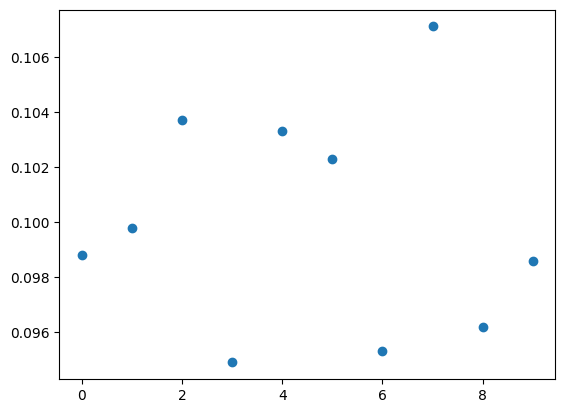

In [3]:
p = Empirical(jnp.arange(10).reshape(-1,1))
samples = p.sample(key, (10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

# SDEs

In [ ]:
drift_matrix = sde.drift 
diffusion_matrix = sde.diffusion

from probjax.utils.odeint import odeint


def filter(drift_matrix, diffusion_matrix, ts, mu0, cov0):
    def f(t, data):
        mu, cov = data
        drift = drift_matrix(mu, t)
        diffusion = diffusion_matrix(mu, t)

        dmu = jnp.matmul(drift, mu)
        dcov = jnp.matmul(drift, cov) + jnp.matmul(cov, drift.T) + jnp.matmul(diffusion, diffusion.T)

        return dmu, dcov
    
    return odeint(f, (mu0, cov0), ts)

NameError: name 'sde' is not defined

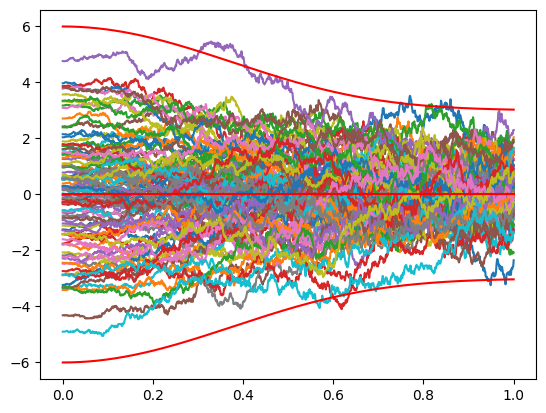

In [ ]:
from probjax.distributions.sde import VPSDE, VESDE

p0 = Normal(jnp.zeros(1), jnp.ones(1)*2)
ts = jnp.linspace(0., 1., 1000)
sde = VPSDE(p0)
mus, covs = filter(sde.drift_matrix, sde.diffusion_matrix, ts, p0.mean, p0.variance)
std = jnp.sqrt(covs)

xs = sde.sample(key, ts,(100,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, jnp.squeeze(mus).T, color="red")
_ = plt.plot(ts, jnp.squeeze(mus).T + 3*jnp.squeeze(std).T, color="red")
_  = plt.plot(ts, jnp.squeeze(mus).T - 3*jnp.squeeze(std).T, color="red")

In [ ]:
jax.random.categorical(key, jnp.ones((100,10)), axis=-1)

Array([8, 0, 6, 8, 9, 4, 7, 6, 9, 9, 4, 9, 5, 1, 7, 0, 3, 7, 8, 0, 1, 1,
       2, 0, 9, 4, 7, 2, 5, 8, 7, 5, 4, 2, 5, 4, 6, 1, 3, 6, 7, 5, 9, 7,
       9, 7, 1, 2, 9, 6, 7, 4, 7, 2, 0, 0, 4, 2, 7, 6, 1, 3, 5, 7, 9, 0,
       1, 3, 9, 4, 0, 9, 7, 6, 5, 6, 9, 3, 1, 9, 9, 8, 7, 6, 8, 1, 7, 8,
       9, 5, 7, 9, 5, 7, 0, 9, 7, 5, 0, 2], dtype=int32)

In [ ]:
jac(0., jnp.array([1.,0.]))

Array([[ 0.,  1.],
       [-1.,  0.]], dtype=float32)

In [ ]:
drift_matrix = sde.drift 
diffusion_matrix = sde.diffusion

from probjax.utils.odeint import odeint


def filter(drift_matrix, diffusion_matrix, ts, mu0, cov0):
    def f(t, data):
        mu, cov = data
        drift = drift_matrix(t)
        diffusion = diffusion_matrix(t)

        dmu = jnp.matmul(drift, mu)
        dcov = jnp.matmul(drift, cov) + jnp.matmul(cov, drift.T) + jnp.matmul(diffusion, diffusion.T)

        return dmu, dcov
    
    return odeint(f, (mu0, cov0), ts)

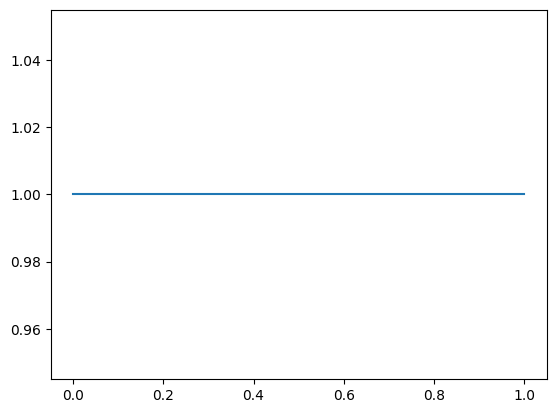

In [ ]:
mus, covs = filter(drift_matrix, diffusion_matrix, ts, jnp.zeros(1), jnp.ones((1,1)))

plt.plot(ts, jnp.squeeze(covs))

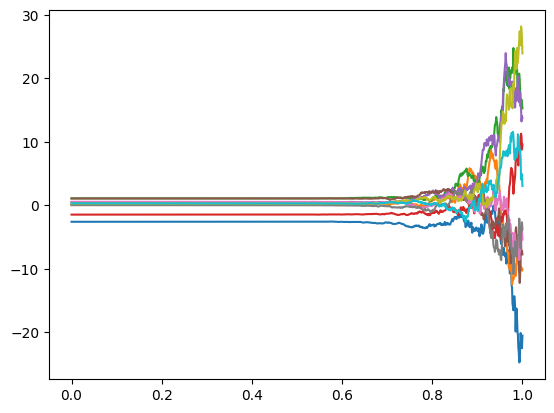

In [ ]:
p0 = Normal(jnp.zeros(1), jnp.ones(1))
ts = jnp.linspace(0., 1., 1000)
sde = VESDE(p0)
mean = sde.mean(ts)
#variance = sde.variance(ts)

xs = sde.sample(key, ts,(10,))
_ = plt.plot(ts, jnp.squeeze(xs).T)

# Transformed Distributon

(0.0, 1.0)

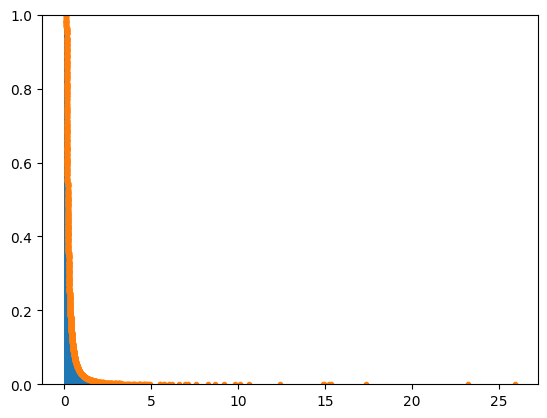

In [ ]:
p0 = Normal(0.,1.)
p = TransformedDistribution(p0, lambda x: jnp.exp(x -2)**2)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

In [ ]:
log_prob

Array([-1.382,  1.856,  4.378, ...,  2.234, -1.316,  0.733], dtype=float32)

# Mixture